## 1️⃣ Set-up

### ✅ Import Libs

In [1]:
import re

import pandas as pd
import numpy as np


import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

from datasist.structdata import detect_outliers

import warnings

### ✅ Set-config

In [2]:
pd.set_option('display.max_columns', None)

warnings.filterwarnings('ignore')

## 2️⃣Data Loading & Exploaring
**Steps:**
- ✅ Load and Check info
- ✅ Check Nulls
- ✅ Check Duplicates

### ✅ Load and Check info

In [3]:
df = pd.read_csv("../data/egypt_real_estate_listings.csv")

In [4]:
df.head()

,url,price,description,location,type,size,bedrooms,bathrooms,available_from,payment_method,down_payment
0,https://www.propertyfinder.eg/en/plp/buy/chale...,"8,000,000",OWN A CHALET IN EL GOUNA WITH A PRIME LOCATION...,"Swan Lake Gouna, Al Gouna, Hurghada, Red Sea",Chalet,732 sqft / 68 sqm,1+ Maid,1,31-Aug-25,Cash,"1,200,000 EGP"
1,https://www.propertyfinder.eg/en/plp/buy/villa...,"25,000,000","For sale, a villa with immediate delivery in C...","Karmell, New Zayed City, Sheikh Zayed City, Giza",Villa,"2,368 sqft / 220 sqm",4,4,2-Sep-25,Cash,"2,100,000 EGP"
2,https://www.propertyfinder.eg/en/plp/buy/chale...,"15,135,000","With a down payment of EGP 1,513,000, a fully ...","Azha North, Ras Al Hekma, North Coast",Chalet,"1,270 sqft / 118 sqm",2,2,19-Aug-25,Cash,"1,513,000 EGP"
3,https://www.propertyfinder.eg/en/plp/buy/apart...,"12,652,000",Own an apartment in New Cairo with a minimal d...,"Taj City, 5th Settlement Compounds, The 5th Se...",Apartment,"1,787 sqft / 166 sqm",3,2,26-Aug-25,Installments,"1,260,000 EGP"
4,https://www.propertyfinder.eg/en/plp/buy/villa...,"45,250,000",Project: Granville\nLocation: Fifth Settlement...,"Granville, New Capital City, Cairo",Villa,"4,306 sqft / 400 sqm",7,7,2-Sep-25,Cash,"2,262,500 EGP"


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19924 entries, 0 to 19923
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   url             19924 non-null  object
 1   price           19385 non-null  object
 2   description     19846 non-null  object
 3   location        19833 non-null  object
 4   type            19847 non-null  object
 5   size            19847 non-null  object
 6   bedrooms        19780 non-null  object
 7   bathrooms       19784 non-null  object
 8   available_from  19261 non-null  object
 9   payment_method  19383 non-null  object
 10  down_payment    5445 non-null   object
dtypes: object(11)
memory usage: 1.7+ MB


In [6]:
df['bathrooms'].unique(),df['bathrooms'].nunique()

(array(['1', '4', '2', '7', '5', '3', '6', '7+', nan, 'none'], dtype=object),
 9)

In [7]:
df['bedrooms'].unique(),df['bedrooms'].nunique()

(array(['1+ Maid', '4', '2', '3', '7', '5+ Maid', '3+ Maid', '2+ Maid',
        '1', '4+ Maid', '7+ Maid', 'studio', '5', '6+ Maid', nan,
        'studio+ Maid', '7++ Maid', '7+', '6'], dtype=object),
 18)

In [8]:
df['price'].unique(),df['price'].nunique()

(array(['8,000,000', '25,000,000', '15,135,000', ..., '5,704,000',
        '7,340,006', '350,000'], shape=(4287,), dtype=object),
 4286)

In [9]:
df['size'].unique(),df['size'].nunique()

(array(['732 sqft / 68 sqm', '2,368 sqft / 220 sqm',
        '1,270 sqft / 118 sqm', '1,787 sqft / 166 sqm',
        '4,306 sqft / 400 sqm', '1,356 sqft / 126 sqm',
        '2,820 sqft / 262 sqm', '3,983 sqft / 370 sqm',
        '2,099 sqft / 195 sqm', '807 sqft / 75 sqm',
        '1,507 sqft / 140 sqm', '1,722 sqft / 160 sqm',
        '797 sqft / 74 sqm', '1,378 sqft / 128 sqm', '689 sqft / 64 sqm',
        '1,615 sqft / 150 sqm', '775 sqft / 72 sqm',
        '1,345 sqft / 125 sqm', '1,830 sqft / 170 sqm',
        '1,076 sqft / 100 sqm', '1,582 sqft / 147 sqm',
        '840 sqft / 78 sqm', '2,583 sqft / 240 sqm',
        '2,013 sqft / 187 sqm', '484 sqft / 45 sqm',
        '1,647 sqft / 153 sqm', '2,002 sqft / 186 sqm',
        '1,098 sqft / 102 sqm', '2,799 sqft / 260 sqm',
        '635 sqft / 59 sqm', '4,338 sqft / 403 sqm', '764 sqft / 71 sqm',
        '1,119 sqft / 104 sqm', '1,023 sqft / 95 sqm',
        '1,496 sqft / 139 sqm', '2,809 sqft / 261 sqm',
        '915 sqft / 85 sqm',

### ✅ Check Nulls

In [10]:
(df.isnull().sum().sort_values(ascending=False))/df.shape[0]*100

down_payment      72.671150
available_from     3.327645
payment_method     2.715318
price              2.705280
bedrooms           0.722746
bathrooms          0.702670
location           0.456736
description        0.391488
size               0.386469
type               0.386469
url                0.000000
dtype: float64

### ✅ Check Duplicates

In [11]:
df.drop(['url','down_payment'],axis=1,inplace=True)
df.duplicated().sum()

np.int64(178)

## 3️⃣ Data Cleaning

Steps:

*   ✅ Data Cleaning
      1.   Fix Data Type
      2.   Drop Duplicated
      3.   Dealing With Missing Values

### ✅ Data Cleaning

#### 1. Fix Data Type

In [12]:
# Fix Price Column
df['price'] = df['price'].str.replace(',','').astype(float)

In [13]:
# create new column
df['is_bathrooms_7plus'] = df['bathrooms'].apply(lambda x: 1 if x == '7+' else 0)
# fix data type for bathrooms
df['bathrooms'] = pd.to_numeric(df['bathrooms'].apply(
    lambda x: 7 if x == '7+' else (np.nan if x == 'none' else x)
),errors='coerce')

In [14]:
# create ne columns
df['studio_flag'] = df['bedrooms'].str.contains('studio', case=False, na=False).astype(int)
df['maid_room'] = df['bedrooms'].str.contains('Maid', case=False, na=False).astype(int)
df['bedrooms_7plus_flag'] = df['bedrooms'].str.contains('7\+', na=False).astype(int)

# fix data type for bedrooms
def clean_bedrooms(x):
    if pd.isna(x):
        return np.nan

    x = x.lower()

    if 'studio' in x:
        return 0
    elif '7+' in x:
        return 7
    else:
        return int(x.split('+')[0].strip())


df['bedrooms'] = df['bedrooms'].apply(clean_bedrooms)

In [15]:
def size_m(x):
  try:
    m = x.split('/')[1].split(' ')[1]
    m = m.replace(",",'')
    return float(m)
  except:
    return x
df['size_metters'] = df['size'].apply(size_m)
df.drop('size',axis=1,inplace=True)

In [16]:
df['available_from'] = pd.to_datetime(df['available_from'])

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19924 entries, 0 to 19923
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   price                19385 non-null  float64       
 1   description          19846 non-null  object        
 2   location             19833 non-null  object        
 3   type                 19847 non-null  object        
 4   bedrooms             19780 non-null  float64       
 5   bathrooms            19779 non-null  float64       
 6   available_from       19261 non-null  datetime64[ns]
 7   payment_method       19383 non-null  object        
 8   is_bathrooms_7plus   19924 non-null  int64         
 9   studio_flag          19924 non-null  int64         
 10  maid_room            19924 non-null  int64         
 11  bedrooms_7plus_flag  19924 non-null  int64         
 12  size_metters         19847 non-null  float64       
dtypes: datetime64[ns](1), float64(4

#### 2. Drop Duplicated

In [18]:
df.drop_duplicates(inplace=True)
df.reset_index(drop=True,inplace=True)

#### 3. Dealing With Missing Values

In [19]:
df.isnull().sum().sort_values(ascending=False)

available_from         584
payment_method         463
price                  461
bathrooms               55
bedrooms                54
location                15
description              2
type                     1
size_metters             1
is_bathrooms_7plus       0
studio_flag              0
maid_room                0
bedrooms_7plus_flag      0
dtype: int64

In [20]:
for i in range(10):
  print(df[df['price'].isna()].reset_index(drop=True)['description'][i])
  print("#"*100)

Silver Sands in Sidi Heneish, North Coast is an artwork by Ora
Penthouse chalet
Building G+1
223 + 58 m roof
1 master bedroom
2 bedrooms
1 nanny's room with private bathroom
Down payment 17.5 m
The rest 2.2 million over 3 years
Delivery 2026
Fully finished
Silver Sands in Sidi Heneish, North Coast is an artwork by Ora Developers rolling over 506 acres (2,112,600 SQM) of land. The project is created to be a summer resort, an easy-peasy weekend destination, and an all-year-season gateway.
Nightlife venues
Swimming pools
1.2 km tree-lined spine & vast verdant landscapes
Swimmable lagoons stretched across 88,000 SQM
Health & wellness facilities including luxurious spas
Open-air cinema
Sports facilities including multipurpose courts and well-equipped gyms
Besides the world-class facilities, Silver Sands North Coast is home to a notable selection of properties scattered across different phases of development.
###################################################################################

In [21]:
nulls_price = df[df['price'].isna()].reset_index(drop=True)

In [22]:
import re
import numpy as np
import pandas as pd

def extract_final_price(text):

    if pd.isna(text):
        return np.nan

    text = str(text).lower()

    def normalize(num, unit=''):
        if not num:
            return np.nan

        num = num.replace(',', '').replace('.', '')

        if not num.isdigit():
            return np.nan

        value = float(num)

        if unit in ['m', 'million']:
            value *= 1_000_000

        return value

    # 1️⃣ TRY DIRECT TOTAL PRICE
    total_patterns = [
        r'total price[:\s]*([\d\.,]+)\s*(m|million)?',
        r'price[:\s]*([\d\.,]+)\s*(m|million)?',
        r'السعر الإجمالى[:\s]*([\d\.,]+)',
        r'([\d\.,]+)\s*(m|million)\s*egp',
        r'([\d\.,]+)\s*egp'
    ]

    total = np.nan

    for p in total_patterns:
        m = re.search(p, text)
        if m:
            groups = m.groups()
            num = groups[0]
            unit = groups[1] if len(groups) > 1 and groups[1] else ''
            total = normalize(num, unit)
            if not pd.isna(total):
                return total  # ✅ STOP EARLY (best case)

    # 2️⃣ TRY DOWN PAYMENT
    down = np.nan
    down_patterns = [
        r'down payment[:\s]*([\d\.,]+)\s*(m|million)?',
        r'مقدم[:\s]*([\d\.,]+)'
    ]

    for p in down_patterns:
        m = re.search(p, text)
        if m:
            groups = m.groups()
            num = groups[0]
            unit = groups[1] if len(groups) > 1 and groups[1] else ''
            down = normalize(num, unit)
            break

    # 3️⃣ TRY REMAINING
    remain = np.nan
    remain_patterns = [
        r'remaining[:\s]*([\d\.,]+)\s*(m|million)?',
        r'the rest[:\s]*([\d\.,]+)\s*(m|million)?',
        r'المتبقي[:\s]*([\d\.,]+)'
    ]

    for p in remain_patterns:
        m = re.search(p, text)
        if m:
            groups = m.groups()
            num = groups[0]
            unit = groups[1] if len(groups) > 1 and groups[1] else ''
            remain = normalize(num, unit)
            break

    # 4️⃣ FALLBACK: SUM COMPONENTS
    if not pd.isna(down) and not pd.isna(remain):
        return down + remain

    return np.nan

In [23]:
nulls_price['price'] = nulls_price['description'].apply(extract_final_price)

In [24]:
filled = df['price'].isnull().sum() - nulls_price['price'].isna().sum()
remaining_nulls = nulls_price['price'].isna().sum()

print(f"Now we filled prices for {filled} units.")
print(f"Now total nulls in price column: {remaining_nulls}")

Now we filled prices for 104 units.
Now total nulls in price column: 357


In [25]:
# new Data
data = pd.concat((df.dropna(subset='price'),nulls_price.dropna(subset='price')),axis=0).reset_index(drop=True)
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19389 entries, 0 to 19388
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   price                19389 non-null  float64       
 1   description          19388 non-null  object        
 2   location             19380 non-null  object        
 3   type                 19389 non-null  object        
 4   bedrooms             19338 non-null  float64       
 5   bathrooms            19337 non-null  float64       
 6   available_from       18834 non-null  datetime64[ns]
 7   payment_method       19283 non-null  object        
 8   is_bathrooms_7plus   19389 non-null  int64         
 9   studio_flag          19389 non-null  int64         
 10  maid_room            19389 non-null  int64         
 11  bedrooms_7plus_flag  19389 non-null  int64         
 12  size_metters         19389 non-null  float64       
dtypes: datetime64[ns](1), float64(4

In [26]:
data.isnull().sum().sort_values(ascending=False)

available_from         555
payment_method         106
bathrooms               52
bedrooms                51
location                 9
description              1
price                    0
type                     0
is_bathrooms_7plus       0
studio_flag              0
maid_room                0
bedrooms_7plus_flag      0
size_metters             0
dtype: int64

In [27]:
def extract_payment_method(text):
    if pd.isna(text):
        return np.nan

    text = str(text).lower()

    # Cash patterns
    cash_patterns = [
        r'\bcash\b',
        r'\bكاش\b'
    ]

    # Installment patterns
    installment_patterns = [
        r'installment',
        r'installments',
        r'flexible payment',
        r'تقسيط'
    ]

    for p in cash_patterns:
        if re.search(p, text):
            return 'Cash'

    for p in installment_patterns:
        if re.search(p, text):
            return 'Installments'

    return np.nan

In [28]:
data[data['payment_method'].isnull()]['description'].apply(extract_payment_method).isnull().sum()

np.int64(67)

In [29]:
mask = data['payment_method'].isnull()
data.loc[mask, 'payment_method'] = data.loc[mask, 'description'].apply(extract_payment_method)

In [30]:
data.isnull().sum().sort_values(ascending=False)

available_from         555
payment_method          67
bathrooms               52
bedrooms                51
location                 9
description              1
price                    0
type                     0
is_bathrooms_7plus       0
studio_flag              0
maid_room                0
bedrooms_7plus_flag      0
size_metters             0
dtype: int64

In [31]:
# also we can make another def for bath and bedrooms but i will not.
# and i don't want to fill this rows with un real data, so i will remove it.
# but i will deal with the date in another way:
#   1.Keep rows
#   2.Extract year/month/week
#   3. Add date_missing flag
#   4. Median impute
# now, we will moving to EDA 
data.dropna(subset=['payment_method','bathrooms','bedrooms','location'],inplace=True)
data.drop('description',axis=1,inplace=True)
data.reset_index(drop=True,inplace=True)

In [32]:
data

,price,location,type,bedrooms,bathrooms,available_from,payment_method,is_bathrooms_7plus,studio_flag,maid_room,bedrooms_7plus_flag,size_metters
0,8000000.0,"Swan Lake Gouna, Al Gouna, Hurghada, Red Sea",Chalet,1.0,1.0,2025-08-31,Cash,0,0,1,0,68.0
1,25000000.0,"Karmell, New Zayed City, Sheikh Zayed City, Giza",Villa,4.0,4.0,2025-09-02,Cash,0,0,0,0,220.0
2,15135000.0,"Azha North, Ras Al Hekma, North Coast",Chalet,2.0,2.0,2025-08-19,Cash,0,0,0,0,118.0
3,12652000.0,"Taj City, 5th Settlement Compounds, The 5th Se...",Apartment,3.0,2.0,2025-08-26,Installments,0,0,0,0,166.0
4,45250000.0,"Granville, New Capital City, Cairo",Villa,7.0,7.0,2025-09-02,Cash,0,0,0,0,400.0
...,...,...,...,...,...,...,...,...,...,...,...,...
19263,24000000.0,"Mountain View October Park, 6th District, 6 Oc...",Townhouse,3.0,3.0,2025-09-02,Installments,0,0,1,0,232.0
19264,2600000.0,"Stone Park, 5th Settlement Compounds, The 5th ...",Townhouse,4.0,4.0,2025-09-02,Installments,0,0,1,0,235.0
19265,29974880.0,"Hills of one, New Zayed City, Sheikh Zayed Cit...",Villa,4.0,3.0,2025-09-01,Cash,0,0,0,0,265.0
19266,4000000.0,"Stone Park, 5th Settlement Compounds, The 5th ...",Villa,4.0,3.0,2025-08-31,Cash,0,0,1,0,244.0


## 4️⃣ Exploratory Data Analysis
**Steps:**

*   ✅ General Overview
      1. Descriptive stats
      2. Outliers Detection
      3. Skew
*   ✅ Target Analysis
      1. Distribution
      2. Box plot
      3. Kolmogorov–Smirnov  (large data)
*   ✅ Features Analysis
      1. Numeric Features
      2. Categorical Features

### ✅ General Overview

#### 1. Descriptive stats

In [33]:
data.describe().T

,count,mean,min,25%,50%,75%,max,std
price,19268.0,16428095.060826,186900.0,6000000.0,10400000.0,18296475.0,840000000.0,23599968.984546
bedrooms,19268.0,2.957858,0.0,2.0,3.0,3.0,7.0,1.160807
bathrooms,19268.0,2.93414,1.0,2.0,3.0,4.0,7.0,1.279845
available_from,18723,2025-08-21 12:56:34.071462912,2023-06-14 00:00:00,2025-08-19 00:00:00,2025-08-31 00:00:00,2025-09-01 00:00:00,2027-10-31 00:00:00,NaN
is_bathrooms_7plus,19268.0,0.007525,0.0,0.0,0.0,0.0,1.0,0.086424
studio_flag,19268.0,0.016919,0.0,0.0,0.0,0.0,1.0,0.128972
maid_room,19268.0,0.46611,0.0,0.0,0.0,1.0,1.0,0.498863
bedrooms_7plus_flag,19268.0,0.010432,0.0,0.0,0.0,0.0,1.0,0.101605
size_metters,19268.0,1035.724777,1.0,126.0,170.0,238.0,15811692.0,113910.19616


In [34]:
data.describe(include="O").T

,count,unique,top,freq
location,19268,1525,"Marassi, Sidi Abdel Rahman, North Coast",417
type,19268,14,Apartment,8263
payment_method,19268,2,Cash,15405


#### 2. Outliers Detection

In [35]:
Q1 = data['price'].quantile(0.25)
Q3 = data['price'].quantile(0.75)
IQR = Q3-Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

In [36]:
data[data['price'] < lower_bound]

,price,location,type,bedrooms,bathrooms,available_from,payment_method,is_bathrooms_7plus,studio_flag,maid_room,bedrooms_7plus_flag,size_metters


In [37]:
data[data['price'] > upper_bound]

,price,location,type,bedrooms,bathrooms,available_from,payment_method,is_bathrooms_7plus,studio_flag,maid_room,bedrooms_7plus_flag,size_metters
4,45250000.0,"Granville, New Capital City, Cairo",Villa,7.0,7.0,2025-09-02,Cash,0,0,0,0,400.0
35,71500000.0,"Belle Vie, New Zayed City, Sheikh Zayed City, ...",Villa,7.0,5.0,2025-08-17,Installments,0,0,1,1,403.0
64,39200000.0,"Ogami, Ras Al Hekma, North Coast",Villa,4.0,4.0,2025-09-02,Installments,0,0,1,0,301.0
83,60000000.0,"Soul North Coast, Qesm Ad Dabaah, North Coast",Villa,4.0,4.0,2025-08-25,Cash,0,0,1,0,800.0
85,60000000.0,"Ramla Lakeside, Qesm Ad Dabaah, North Coast",Villa,5.0,5.0,2025-08-31,Cash,0,0,1,0,670.0
...,...,...,...,...,...,...,...,...,...,...,...,...
19233,37764285.0,"Soul North Coast, Qesm Ad Dabaah, North Coast",Townhouse,3.0,4.0,2025-08-28,Installments,0,0,1,0,193.0
19234,70000000.0,"Touristic 1, Northern Expansions, 6 October Ci...",Villa,7.0,7.0,2025-08-30,Cash,1,0,1,1,1305.0
19244,37446792.0,"Solana, New Zayed City, Sheikh Zayed City, Giza",Villa,4.0,5.0,2025-09-01,Cash,0,0,1,0,337.0
19250,56477000.0,"Soul North Coast, Qesm Ad Dabaah, North Coast",Villa,3.0,3.0,2025-08-31,Installments,0,0,1,0,341.0


#### 3. Skew

In [38]:
data['price'].skew()

np.float64(8.988317239676132)

In [39]:
for col in data.select_dtypes(include='number').columns:
    print(f"skew for {col} column is:{data[col].skew()}")

skew for price column is:8.988317239676132
skew for bedrooms column is:0.5103196870861961
skew for bathrooms column is:0.7807975919764698
skew for is_bathrooms_7plus column is:11.397831708370346
skew for studio_flag column is:7.492012023334388
skew for maid_room column is:0.13588460941625446
skew for bedrooms_7plus_flag column is:9.637722771039996
skew for size_metters column is:138.80111977329264


### ✅ Target Analysis

#### 1. Distribution

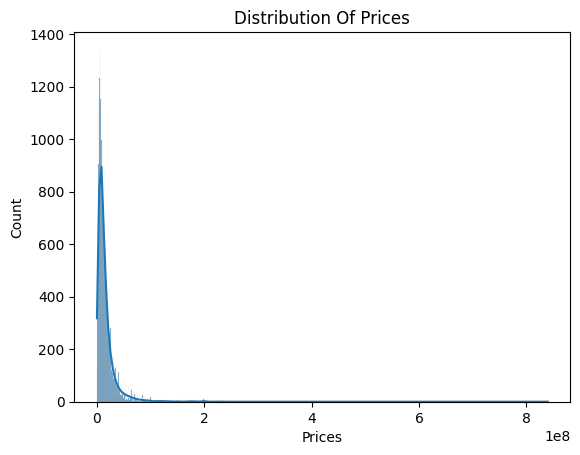

In [40]:
plt.Figure(figsize=(10,18))
sns.histplot(x = data['price'],kde=True)
plt.xlabel("Prices")
plt.title('Distribution Of Prices')
plt.show()

#### 2. Box plot

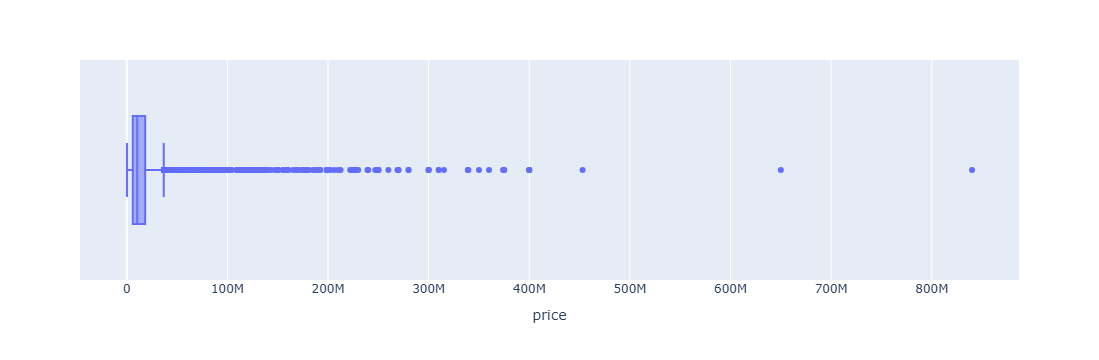

In [41]:
fig = px.box(data,x = 'price')
fig.show()

#### 3. Kolmogorov–Smirnov

In [42]:
from scipy.stats import kstest
import numpy as np

price = data['price'].dropna()
price_std = (price - price.mean()) / price.std()

stat, p_value = kstest(price_std, 'norm')

print("KS Statistic:", stat)
print("p-value:", p_value)

KS Statistic: 0.25274922938365585
p-value: 0.0


### ✅ Feature Analysis

#### 1. Numeric Features

##### Correlation Matrix

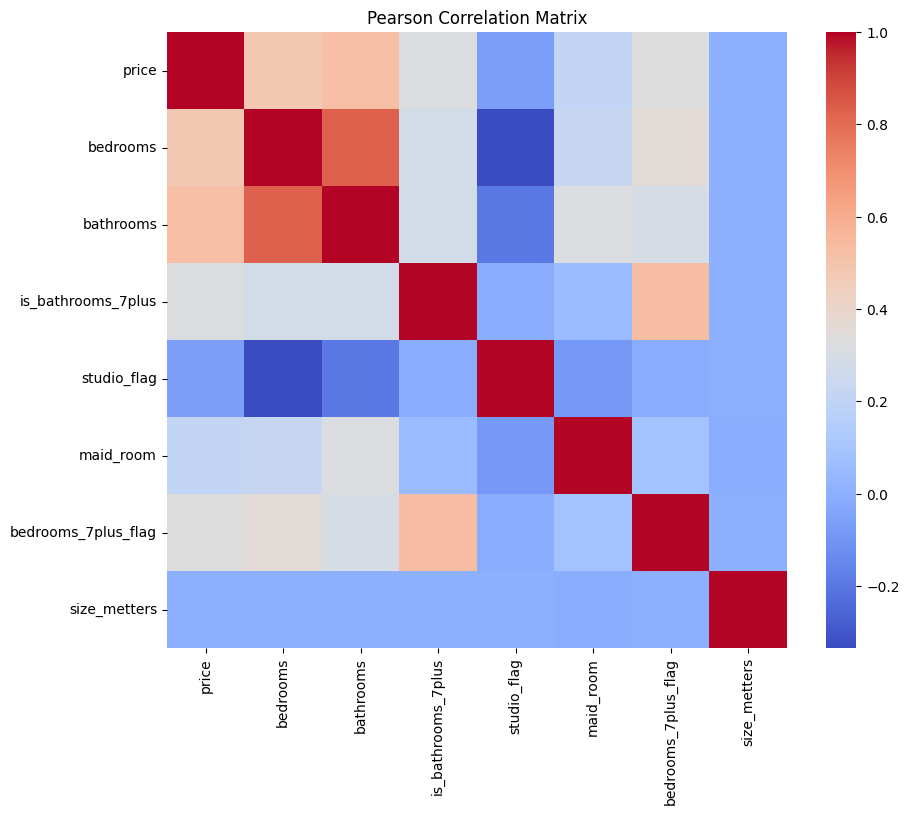

In [43]:
corr_matrix = data.corr(method='pearson',numeric_only=True)

plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, cmap="coolwarm", annot=False)
plt.title("Pearson Correlation Matrix")
plt.show()

##### Multicollinearity

In [44]:
from statsmodels.stats.outliers_influence import variance_inflation_factor


# Step 1: select numeric columns only
numeric_cols = data.select_dtypes(include=['number']).columns

# Step 2: drop target + non-numeric date columns
X_vif = data[numeric_cols].drop(columns=['price'], errors='ignore')

# Step 3: convert all to float
X_vif = X_vif.astype(float)

# Step 4: compute VIF
vif_data = pd.DataFrame()
vif_data["Feature"] = X_vif.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]

print(vif_data.sort_values(by="VIF", ascending=False))

               Feature        VIF
1            bathrooms  22.462533
0             bedrooms  21.017813
4            maid_room   2.081579
5  bedrooms_7plus_flag   1.451462
2   is_bathrooms_7plus   1.432689
3          studio_flag   1.036690
6         size_metters   1.000132


#### 2. Categorical Features

In [45]:
data.select_dtypes(include='object').columns

Index(['location', 'type', 'payment_method'], dtype='object')

In [46]:
data['location'].value_counts().head(25)

location
Marassi, Sidi Abdel Rahman, North Coast                                                         417
Mountain View iCity, 5th Settlement Compounds, The 5th Settlement, New Cairo City, Cairo        387
Madinaty, Cairo                                                                                 356
Hyde Park, 5th Settlement Compounds, The 5th Settlement, New Cairo City, Cairo                  351
Palm Hills New Cairo, 5th Settlement Compounds, The 5th Settlement, New Cairo City, Cairo       319
Silver Sands, Qesm Marsa Matrouh, North Coast                                                   281
O West, 6 October Compounds, 6 October City, Giza                                               280
Sarai, Mostakbal City Compounds, Mostakbal City - Future City, Cairo                            261
Mountain View iCity October, 6 October Compounds, 6 October City, Giza                          255
Mivida, 5th Settlement Compounds, The 5th Settlement, New Cairo City, Cairo                

In [47]:
data['payment_method'].value_counts()

payment_method
Cash            15405
Installments     3863
Name: count, dtype: int64

In [48]:
data['type'].value_counts()

type
Apartment          8263
Chalet             3926
Villa              3392
Townhouse          1277
Twin House          796
Duplex              610
Penthouse           559
iVilla              261
Hotel Apartment     101
Cabin                36
Palace               23
Whole Building       14
Roof                  6
Full Floor            4
Name: count, dtype: int64

In [49]:
from scipy.stats import kruskal

cat_cols = data.select_dtypes(include='object').columns

results = []

for col in cat_cols:
    df = data[[col, 'price']].dropna()
    groups = [g['price'].values for _, g in df.groupby(col)]
    
    if len(groups) > 1:
        stat, p = kruskal(*groups)
        results.append((col, p))

results_df = pd.DataFrame(results, columns=['feature','p_value']).sort_values('p_value')
results_df

,feature,p_value
0,location,0.000000e+00
1,type,0.000000e+00
2,payment_method,1.071928e-08


## 5️⃣ Features Engineering and Preparing

### ✅ Features Engineering

#### 1. Time Features 

In [50]:
data['year'] = data['available_from'].dt.year
data['month'] = data['available_from'].dt.month
data['date_mis'] = data['available_from'].isna().astype(int)

def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:  # 9,10,11
        return 'Autumn'

data['season'] = data['available_from'].dt.month.map(get_season)

In [51]:
data['date_mis'].unique()

array([0, 1])

#### 2. Location Features

In [52]:
def Location_features(df, col='location', max_levels=4):
    
    def _split_one(x):
        if pd.isna(x):
            return [np.nan] * max_levels
        
        parts = [p.strip() for p in str(x).split(',')]
        parts = parts[::-1]  # reverse to start from governorate
        
        # pad if shorter
        parts += [np.nan] * (max_levels - len(parts))
        parts = parts[:max_levels]
        
        return parts[::-1] 

    split_cols = df[col].apply(_split_one).apply(pd.Series)

    split_cols.columns = [
        'compound',
        'district',
        'city',
        'governorate'
    ][:max_levels]

    return pd.concat([df, split_cols], axis=1)


data = Location_features(data, col='location')

#### 3. type
**Merge lowest values as other**

In [53]:
rare_types = [
    'iVilla','Hotel Apartment','Cabin','Palace',
    'Whole Building','Roof','Full Floor'
]

data['type'] = data['type'].replace(rare_types, 'Other')

In [54]:
data

,price,location,type,bedrooms,bathrooms,available_from,payment_method,is_bathrooms_7plus,studio_flag,maid_room,bedrooms_7plus_flag,size_metters,year,month,date_mis,season,compound,district,city,governorate
0,8000000.0,"Swan Lake Gouna, Al Gouna, Hurghada, Red Sea",Chalet,1.0,1.0,2025-08-31,Cash,0,0,1,0,68.0,2025.0,8.0,0,Summer,Swan Lake Gouna,Al Gouna,Hurghada,Red Sea
1,25000000.0,"Karmell, New Zayed City, Sheikh Zayed City, Giza",Villa,4.0,4.0,2025-09-02,Cash,0,0,0,0,220.0,2025.0,9.0,0,Autumn,Karmell,New Zayed City,Sheikh Zayed City,Giza
2,15135000.0,"Azha North, Ras Al Hekma, North Coast",Chalet,2.0,2.0,2025-08-19,Cash,0,0,0,0,118.0,2025.0,8.0,0,Summer,NaN,Azha North,Ras Al Hekma,North Coast
3,12652000.0,"Taj City, 5th Settlement Compounds, The 5th Se...",Apartment,3.0,2.0,2025-08-26,Installments,0,0,0,0,166.0,2025.0,8.0,0,Summer,5th Settlement Compounds,The 5th Settlement,New Cairo City,Cairo
4,45250000.0,"Granville, New Capital City, Cairo",Villa,7.0,7.0,2025-09-02,Cash,0,0,0,0,400.0,2025.0,9.0,0,Autumn,NaN,Granville,New Capital City,Cairo
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19263,24000000.0,"Mountain View October Park, 6th District, 6 Oc...",Townhouse,3.0,3.0,2025-09-02,Installments,0,0,1,0,232.0,2025.0,9.0,0,Autumn,Mountain View October Park,6th District,6 October City,Giza
19264,2600000.0,"Stone Park, 5th Settlement Compounds, The 5th ...",Townhouse,4.0,4.0,2025-09-02,Installments,0,0,1,0,235.0,2025.0,9.0,0,Autumn,5th Settlement Compounds,The 5th Settlement,New Cairo City,Cairo
19265,29974880.0,"Hills of one, New Zayed City, Sheikh Zayed Cit...",Villa,4.0,3.0,2025-09-01,Cash,0,0,0,0,265.0,2025.0,9.0,0,Autumn,Hills of one,New Zayed City,Sheikh Zayed City,Giza
19266,4000000.0,"Stone Park, 5th Settlement Compounds, The 5th ...",Villa,4.0,3.0,2025-08-31,Cash,0,0,1,0,244.0,2025.0,8.0,0,Summer,5th Settlement Compounds,The 5th Settlement,New Cairo City,Cairo


#### 4. Quick Analysis

In [55]:
data.isnull().sum()

price                     0
location                  0
type                      0
bedrooms                  0
bathrooms                 0
available_from          545
payment_method            0
is_bathrooms_7plus        0
studio_flag               0
maid_room                 0
bedrooms_7plus_flag       0
size_metters              0
year                    545
month                   545
date_mis                  0
season                    0
compound               6388
district                493
city                      0
governorate               0
dtype: int64

In [56]:
data.describe(include='O').T

,count,unique,top,freq
location,19268,1525,"Marassi, Sidi Abdel Rahman, North Coast",417
type,19268,8,Apartment,8263
payment_method,19268,2,Cash,15405
season,19268,4,Summer,11949
compound,12880,880,5th Settlement Compounds,3612
district,18775,477,The 5th Settlement,3992
city,19268,69,New Cairo City,5117
governorate,19268,16,Cairo,7430


In [57]:
cat_cols = data.select_dtypes(include='object').columns

results = []

for col in cat_cols:
    df = data[[col, 'price']].dropna()
    groups = [g['price'].values for _, g in df.groupby(col)]
    
    if len(groups) > 1:
        stat, p = kruskal(*groups)
        results.append((col, p))

results_df = pd.DataFrame(results, columns=['feature','p_value']).sort_values('p_value')
results_df

,feature,p_value
0,location,0.000000e+00
1,type,0.000000e+00
5,district,0.000000e+00
4,compound,0.000000e+00
6,city,0.000000e+00
7,governorate,0.000000e+00
3,season,8.260377e-56
2,payment_method,1.071928e-08


In [58]:
data['year'].unique()

array([2025.,   nan, 2026., 2024., 2027., 2023.])

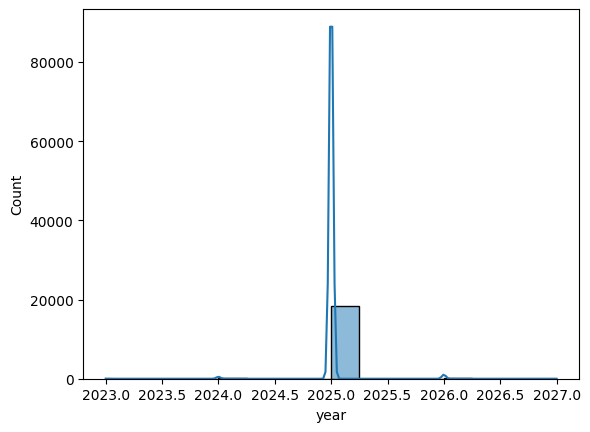

In [59]:
plt.Figure(figsize=(10,8))
sns.histplot(x = data['year'],kde=True)
plt.show()

In [60]:
data['year'].value_counts()

year
2025.0    18445
2026.0      183
2024.0       89
2023.0        5
2027.0        1
Name: count, dtype: int64

In [61]:
data['month'].value_counts()

month
8.0     10222
9.0      6188
7.0      1320
6.0       407
5.0       355
4.0        81
12.0       42
3.0        28
2.0        24
1.0        19
11.0       19
10.0       18
Name: count, dtype: int64

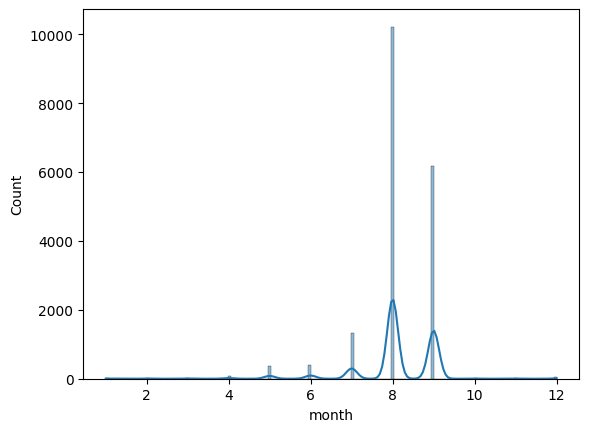

In [62]:
plt.Figure(figsize=(10,8))
sns.histplot(x = data['month'],kde=True)
plt.show()

In [63]:
from scipy.stats import kruskal

groups = [g['price'].values for _, g in data.groupby('month')]
kruskal(*groups)

KruskalResult(statistic=np.float64(364.5064510117197), pvalue=np.float64(2.057823758008965e-71))

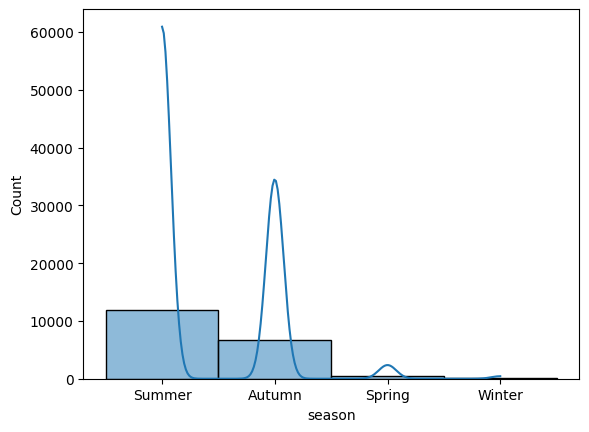

In [64]:
plt.Figure(figsize=(10,8))
sns.histplot(x = data['season'],kde=True)
plt.show()

In [65]:
data['season'].value_counts()

season
Summer    11949
Autumn     6770
Spring      464
Winter       85
Name: count, dtype: int64

In [66]:
for col in data.select_dtypes(include='number').columns:
    print(f"skew for {col} column is:{data[col].skew()}")
    print("  ")

skew for price column is:8.988317239676132
  
skew for bedrooms column is:0.5103196870861961
  
skew for bathrooms column is:0.7807975919764698
  
skew for is_bathrooms_7plus column is:11.397831708370346
  
skew for studio_flag column is:7.492012023334388
  
skew for maid_room column is:0.13588460941625446
  
skew for bedrooms_7plus_flag column is:9.637722771039996
  
skew for size_metters column is:138.80111977329264
  
skew for year column is:1.559622199068002
  
skew for month column is:-2.014480930558753
  
skew for date_mis column is:5.691070175714877
  


### ✅ Data Preparing

#### 1. Skewness Fix

In [67]:
# Log-transform heavy-tailed numeric
data['price_log'] = np.log1p(data['price'])
data['size_log'] = np.log1p(data['size_metters'])

# Cyclic encoding for month
data['month_sin'] = np.sin(2 * np.pi * data['month']/12)
data['month_cos'] = np.cos(2 * np.pi * data['month']/12)

# Drop redundant features
data = data.drop(columns=['location','compound','available_from','year', 'price', 'size_metters', 'month'])

In [68]:
data[['price_log','size_log']].skew()

price_log    0.187497
size_log     0.933666
dtype: float64

#### 2. Fill na

In [69]:
data.isnull().sum().sort_values(ascending=False)

month_cos              545
month_sin              545
district               493
type                     0
bedrooms                 0
studio_flag              0
bathrooms                0
payment_method           0
is_bathrooms_7plus       0
date_mis                 0
bedrooms_7plus_flag      0
maid_room                0
season                   0
governorate              0
city                     0
size_log                 0
price_log                0
dtype: int64

In [70]:
numeric_cols = ['month_sin', 'month_cos']
for col in numeric_cols:
    data[col].fillna(0, inplace=True)  # 0 = missing month

data['district'].fillna('Unknown', inplace=True)

#### 4. Add Clustring

### ✅ 11. Clustring

In [71]:
# Machine learning models & tools
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, LabelEncoder, StandardScaler , RobustScaler  , MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans 
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.manifold import TSNE
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from category_encoders import TargetEncoder

#### 1. Encode Data

In [72]:
data.select_dtypes(include='object').columns

Index(['type', 'payment_method', 'season', 'district', 'city', 'governorate'], dtype='object')

In [73]:
for col in data.select_dtypes(include='object').columns:
    print(f"""{col} --> Nunique = {data[col].nunique()}""")

type --> Nunique = 8
payment_method --> Nunique = 2
season --> Nunique = 4
district --> Nunique = 478
city --> Nunique = 69
governorate --> Nunique = 16


In [74]:
bina = ['district','city','payment_method','governorate']  # categorical
onh = ['type','season']  # categorical with few categories

encoder = ColumnTransformer(
    transformers=[
        (
            'onehot_type',
            OneHotEncoder(handle_unknown='ignore'),
            onh
        ), 
        (
           'ordinal_other',
            OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1),
            bina
        )
    ],
    remainder='passthrough'
)

#### 2. Steps

In [75]:
steps = [
    ('Encoding',encoder),
    ('Scaling',StandardScaler()),
    ("Model",KMeans())
]

#### 3. Optimal Cluster

In [76]:
def Optimal_cluster(data, encoder, n_max=7):

    wcss = []
    silhouette_scores = []
    calinski_scores = []
    davies_scores = []

    cluster_range = range(2, n_max + 1)

    # preprocessing فقط
    preprocess = Pipeline([
        ('Encoding', encoder),
        ('Scaling', StandardScaler())
    ])

    X_transformed = preprocess.fit_transform(data)

    for k in cluster_range:
        kmeans = KMeans(
            n_clusters=k,
            random_state=42,
            n_init=20,
            init='k-means++'
        )

        labels = kmeans.fit_predict(X_transformed)

        # WCSS (Elbow)
        wcss.append(kmeans.inertia_)

        # Metrics
        silhouette_scores.append(silhouette_score(X_transformed, labels))
        calinski_scores.append(calinski_harabasz_score(X_transformed, labels))
        davies_scores.append(davies_bouldin_score(X_transformed, labels))

    print(f"The Optimal n_clusters by Elbow Method is: {np.argmin(wcss)+2}") # +2 because range starts from 2
    print(f"The Optimal n_clusters by Silhouette Score is: { np.argmax(silhouette_scores) + 2}")
    print(f"The Optimal n_clusters by Calinski Score is: {np.argmax(calinski_scores) + 2}")
    print(f"The Optimal n_clusters by Davies Score is: {np.argmin(davies_scores) + 2}")
   

    

    suggestions = [
        np.argmin(wcss) + 2,
        np.argmax(silhouette_scores) + 2,
        np.argmax(calinski_scores) + 2,
        np.argmin(davies_scores) + 2
    ]

    optimal_k = max(set(suggestions), key=suggestions.count)
    print(f"Consensus optimal clusters: {optimal_k}") # most frequently suggested number of clusters

    return wcss, silhouette_scores, calinski_scores, davies_scores, cluster_range

In [77]:
wcss,silhouette_scores,calinski_scores,davies_scores,cluster_range=Optimal_cluster(data=data,n_max=20,encoder=encoder) # apply the function

The Optimal n_clusters by Elbow Method is: 20
The Optimal n_clusters by Silhouette Score is: 16
The Optimal n_clusters by Calinski Score is: 17
The Optimal n_clusters by Davies Score is: 15
Consensus optimal clusters: 16


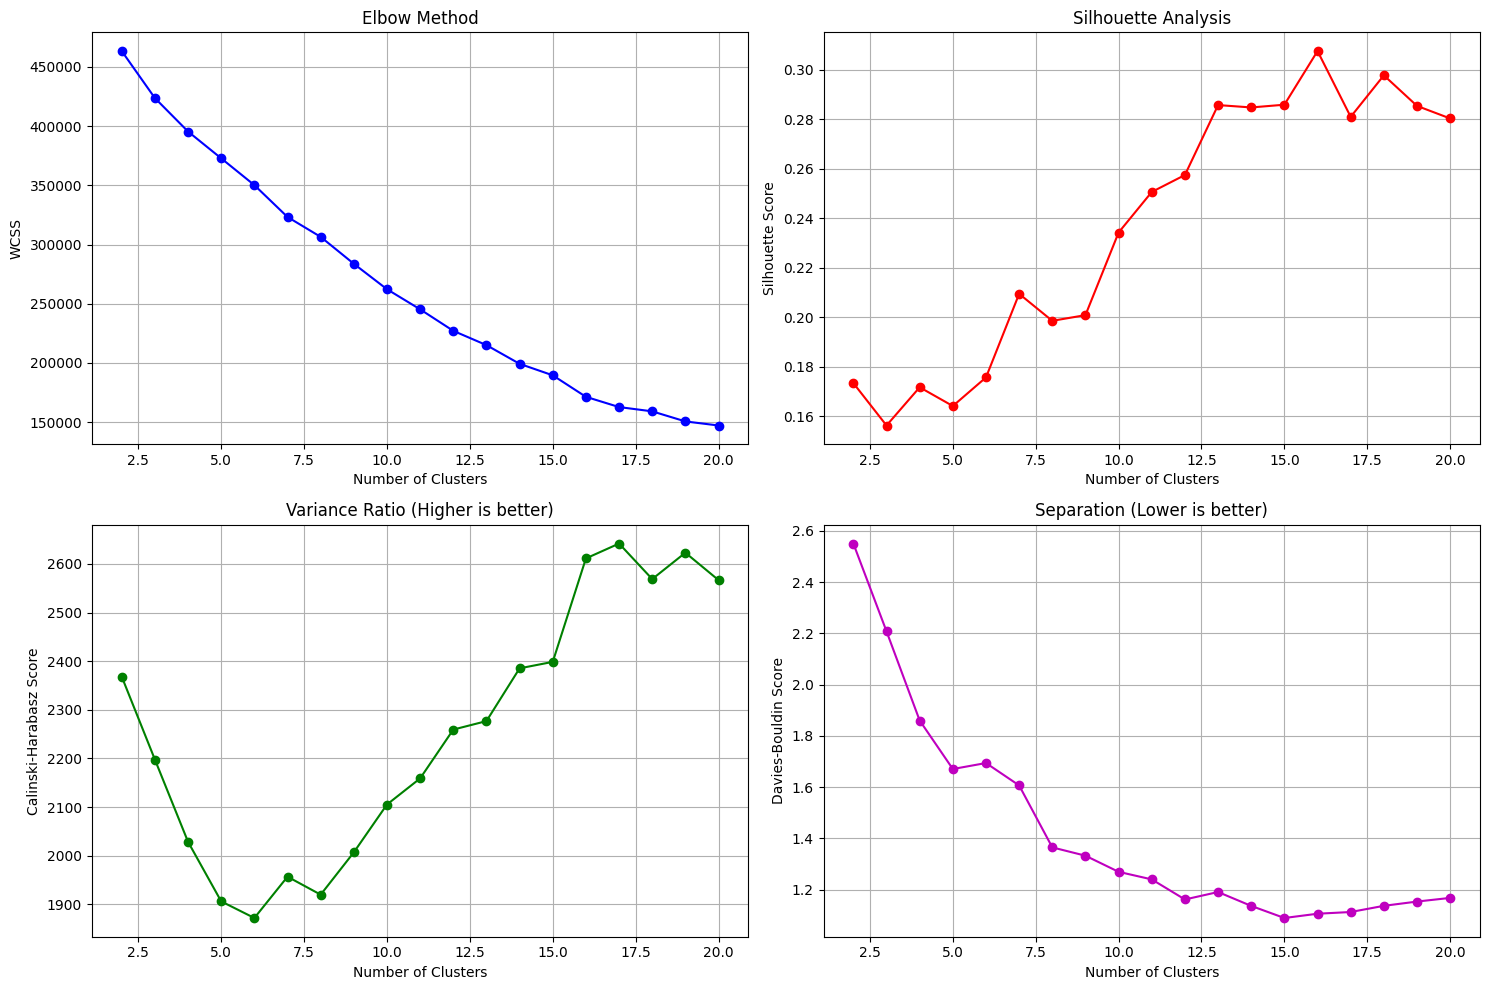

In [78]:
# Now plot all metrics
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 10))

# Elbow Method (WCSS)
ax1.plot(cluster_range, wcss, 'bo-')
ax1.set_xlabel('Number of Clusters')
ax1.set_ylabel('WCSS')
ax1.set_title('Elbow Method')
ax1.grid(True)

# Silhouette Score
ax2.plot(cluster_range, silhouette_scores, 'ro-')
ax2.set_xlabel('Number of Clusters')
ax2.set_ylabel('Silhouette Score')
ax2.set_title('Silhouette Analysis')
ax2.grid(True)

# Calinski-Harabasz Score (Higher is better)
ax3.plot(cluster_range, calinski_scores, 'go-')
ax3.set_xlabel('Number of Clusters')
ax3.set_ylabel('Calinski-Harabasz Score')
ax3.set_title('Variance Ratio (Higher is better)')
ax3.grid(True)

# Davies-Bouldin Score (Lower is better)
ax4.plot(cluster_range, davies_scores, 'mo-')
ax4.set_xlabel('Number of Clusters')
ax4.set_ylabel('Davies-Bouldin Score')
ax4.set_title('Separation (Lower is better)')
ax4.grid(True)

plt.tight_layout()
plt.show()

#### 4. Hyper Parameter

In [79]:
# let's tune hyperparameters for KMeans we can use it evvery time we want to use KMeans
def hyperparameter (data,max_iter_range = 500 , n_clusters = 2,init_algorithem="auto",encoder=encoder,scaler=StandardScaler):

    results = []

    init_algorithems = [
        ('k-means++', 'lloyd'),
        ('random', 'lloyd'),
        ('k-means++', 'elkan'),
        ('random', 'elkan'),
    ]

    if init_algorithem == "auto":
        algos_to_test = init_algorithems
    elif isinstance(init_algorithem, int) and 1 <= init_algorithem <= 4:
        algos_to_test = [init_algorithems[init_algorithem - 1]]
    else:
        raise ValueError("init_algorithem must be 'auto' or integer 1–4")

    # ---------- Preprocessing ----------
    preprocess = Pipeline([
        ('Encoding', encoder),
        ('Scaling', MinMaxScaler())
    ])

    X = preprocess.fit_transform(data)

    # ---------- Grid Search ----------
    for max_iter in range(100, max_iter_range + 1, 100):
        for init, algorithm in algos_to_test:

            model = KMeans(
                n_clusters=n_clusters,
                init=init,
                algorithm=algorithm,
                max_iter=max_iter,
                n_init=20,
                random_state=42
            )

            labels = model.fit_predict(X)

            sil = silhouette_score(X, labels)
            cal = calinski_harabasz_score(X, labels)
            dav = davies_bouldin_score(X, labels)

            results.append({
                "n_clusters": n_clusters,
                "init": init,
                "algorithm": algorithm,
                "max_iter": max_iter,
                "silhouette_score": sil,
                "calinski_harabasz_score": cal,
                "davies_bouldin_score": dav
            })

    results_df = pd.DataFrame(results)

    # ---------- Handle edge case ----------
    if (
        results_df['silhouette_score'].nunique() == 1 and
        results_df['calinski_harabasz_score'].nunique() == 1 and
        results_df['davies_bouldin_score'].nunique() == 1
    ):
        best_row = results_df.iloc[0]

    else:
        scale = scaler()

        results_df[['silhouette_norm', 'calinski_norm']] = scale.fit_transform(
            results_df[['silhouette_score', 'calinski_harabasz_score']]
        )

        results_df['davies_norm'] = 1 - scale.fit_transform(
            results_df[['davies_bouldin_score']]
        )

        results_df['final_score'] = (
            results_df['silhouette_norm'] +
            results_df['calinski_norm'] +
            results_df['davies_norm']
        )

        best_row = results_df.loc[results_df['final_score'].idxmax()]

    # ---------- Refit Best Model ----------
    best_model = KMeans(
        n_clusters=int(best_row['n_clusters']),
        init=best_row['init'],
        algorithm=best_row['algorithm'],
        max_iter=int(best_row['max_iter']),
        n_init=20,
        random_state=42
    )

    labels = best_model.fit_predict(X)

    return results_df, best_row, labels

In [80]:
%%time
results, best_params, labels = hyperparameter(
    data=data,
    encoder=encoder,
    n_clusters=17
)

CPU times: total: 4min 16s
Wall time: 1min 23s


In [81]:
labels

array([4, 5, 3, ..., 5, 6, 2], shape=(19268,), dtype=int32)

In [82]:
data['Clusters'] = labels

In [83]:
data

,type,bedrooms,bathrooms,payment_method,is_bathrooms_7plus,studio_flag,maid_room,bedrooms_7plus_flag,date_mis,season,district,city,governorate,price_log,size_log,month_sin,month_cos,Clusters
0,Chalet,1.0,1.0,Cash,0,0,1,0,0,Summer,Al Gouna,Hurghada,Red Sea,15.894952,4.234107,-0.866025,-5.000000e-01,4
1,Villa,4.0,4.0,Cash,0,0,0,0,0,Autumn,New Zayed City,Sheikh Zayed City,Giza,17.034386,5.398163,-1.000000,-1.836970e-16,5
2,Chalet,2.0,2.0,Cash,0,0,0,0,0,Summer,Azha North,Ras Al Hekma,North Coast,16.532521,4.779123,-0.866025,-5.000000e-01,3
3,Apartment,3.0,2.0,Installments,0,0,0,0,0,Summer,The 5th Settlement,New Cairo City,Cairo,16.353326,5.117994,-0.866025,-5.000000e-01,15
4,Villa,7.0,7.0,Cash,0,0,0,0,0,Autumn,Granville,New Capital City,Cairo,17.627713,5.993961,-1.000000,-1.836970e-16,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19263,Townhouse,3.0,3.0,Installments,0,0,1,0,0,Autumn,6th District,6 October City,Giza,16.993564,5.451038,-1.000000,-1.836970e-16,8
19264,Townhouse,4.0,4.0,Installments,0,0,1,0,0,Autumn,The 5th Settlement,New Cairo City,Cairo,14.771022,5.463832,-1.000000,-1.836970e-16,8
19265,Villa,4.0,3.0,Cash,0,0,0,0,0,Autumn,New Zayed City,Sheikh Zayed City,Giza,17.215870,5.583496,-1.000000,-1.836970e-16,5
19266,Villa,4.0,3.0,Cash,0,0,1,0,0,Summer,The 5th Settlement,New Cairo City,Cairo,15.201805,5.501258,-0.866025,-5.000000e-01,6


In [84]:
x = data.drop(['price_log'],axis=1)
y = data['price_log']

## 6️⃣ Modeling

### ✅ Search Loop

In [85]:
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, MinMaxScaler, RobustScaler, StandardScaler
from category_encoders import TargetEncoder, BinaryEncoder
from sklearn.impute import KNNImputer, SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.feature_selection import SelectFromModel

# Linear Models
from sklearn.linear_model import LinearRegression, Ridge, PassiveAggressiveRegressor

# Tree Models
from sklearn.tree import DecisionTreeRegressor

# Ensemble Models
from sklearn.ensemble import (
    RandomForestRegressor,
    AdaBoostRegressor,
    GradientBoostingRegressor,
    ExtraTreesRegressor,
    IsolationForest
)

# Boosting
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

# Naive Bayes (Not valid for regression → removed)

# Neighbors
from sklearn.neighbors import KNeighborsRegressor

# SVM
from sklearn.svm import SVR, LinearSVR

# Neural Network
from sklearn.neural_network import MLPRegressor

# Metrics for Regression
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    mean_absolute_percentage_error,
    make_scorer
)

import joblib
import warnings
from sklearn.exceptions import ConvergenceWarning

warnings.filterwarnings("ignore", category=ConvergenceWarning)
warnings.filterwarnings("ignore", category=UserWarning)

from sklearn.model_selection import cross_validate, train_test_split

# Time-Series Aware CV
from sklearn.model_selection import TimeSeriesSplit

#### 1. Encoder

In [86]:
bina = ['payment_method','governorate']  # categorical
onh = ['type','season']  # categorical with few categories
targ = ['district','city']
encoder = ColumnTransformer(
    transformers=[
        (
            'onehot_type',
            OneHotEncoder(handle_unknown='ignore'),
            onh
        ), 
        (
           'ordinal_other',
            OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1),
            bina
        ),
        (
            'Target Encoder',
            TargetEncoder(),
            targ
        )
    ],
    remainder='passthrough'
)

#### 2. Models

In [87]:
models = [
    # Linear Models
    ("LinearRegression", LinearRegression()),
    ("Ridge", Ridge()),
    ("PassiveAggressiveRegressor", PassiveAggressiveRegressor()),

    # Tree Models
    ("DecisionTreeRegressor", DecisionTreeRegressor()),

    # Ensemble Models
    ("RandomForestRegressor", RandomForestRegressor()),
    ("AdaBoostRegressor", AdaBoostRegressor()),
    ("GradientBoostingRegressor", GradientBoostingRegressor()),
    ("ExtraTreesRegressor", ExtraTreesRegressor()),

    # Boosting
    ("XGBRegressor", XGBRegressor()),
    ("LGBMRegressor", LGBMRegressor()),
    ("CatBoostRegressor", CatBoostRegressor(verbose=0)),

    # Neighbors
    ("KNeighborsRegressor", KNeighborsRegressor()),

    # SVM
    ("SVR", SVR()),
    ("LinearSVR", LinearSVR()),

    # Neural Network
    ("MLPRegressor", MLPRegressor()),

]

#### 4. For Loop

In [88]:
tscv = TimeSeriesSplit(n_splits=5)


Training: LinearRegression
R2 Train: 0.1414
R2 Test : 0.5060
RMSE Test: 16056079.0741


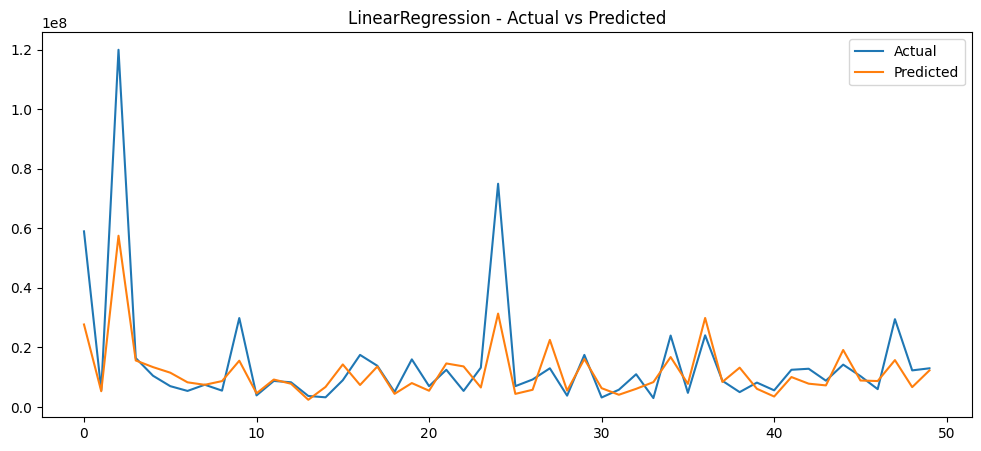


Training: Ridge
R2 Train: 0.1423
R2 Test : 0.5060
RMSE Test: 16056376.6000


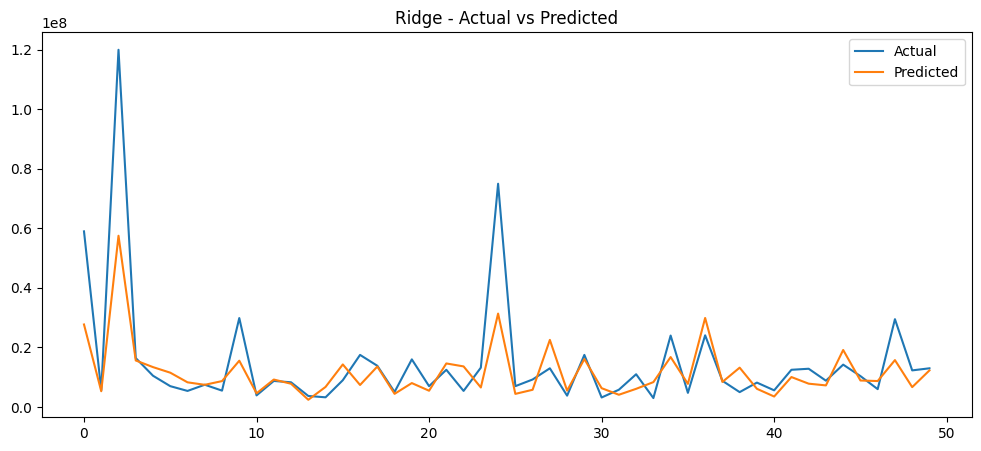


Training: PassiveAggressiveRegressor
R2 Train: -831079.9833
R2 Test : -1.8134
RMSE Test: 38318639.2851


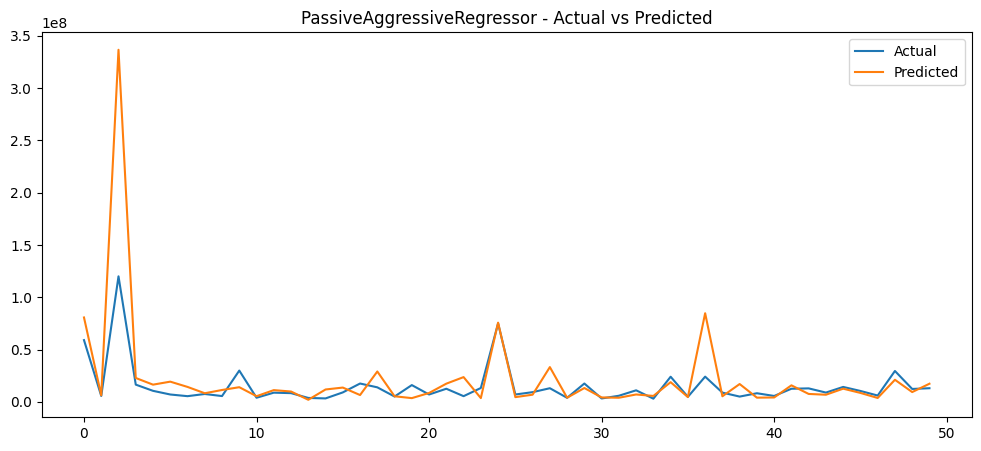


Training: DecisionTreeRegressor
R2 Train: 0.9938
R2 Test : 0.3889
RMSE Test: 17858894.4162


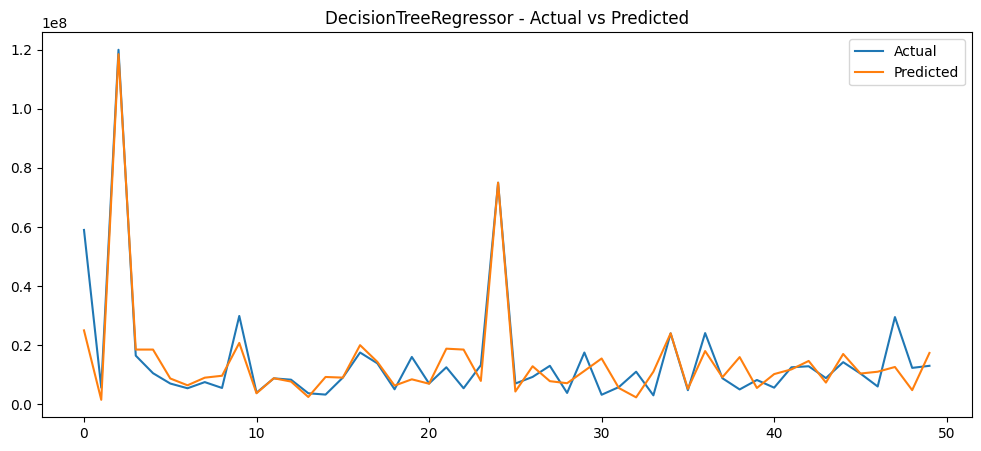


Training: RandomForestRegressor
R2 Train: 0.9255
R2 Test : 0.6750
RMSE Test: 13023868.8767


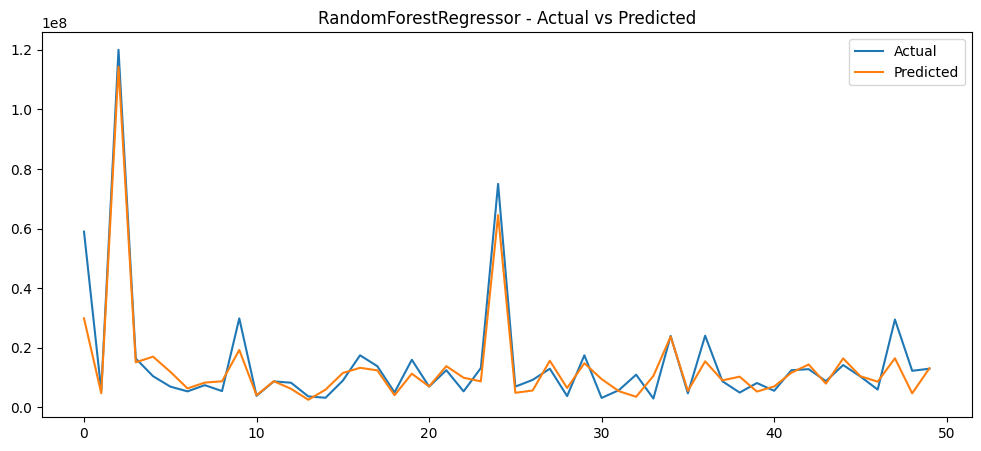


Training: AdaBoostRegressor
R2 Train: 0.4579
R2 Test : 0.4942
RMSE Test: 16246859.3280


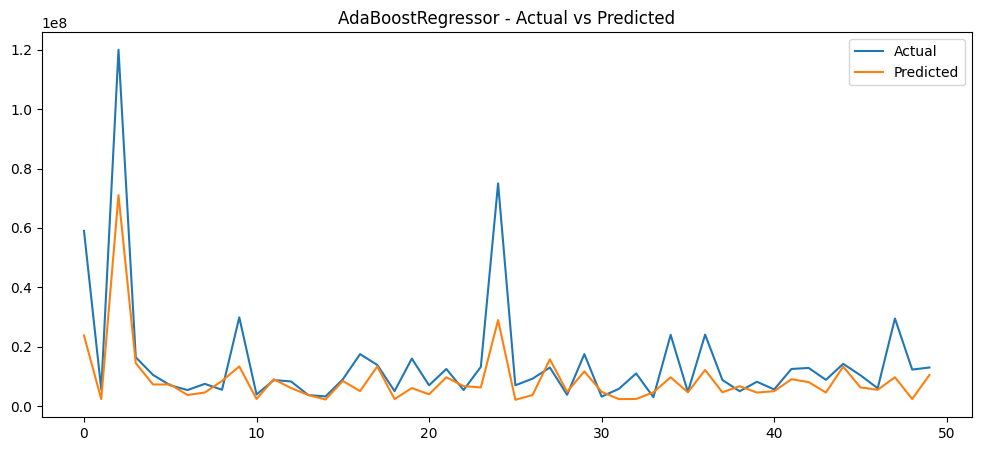


Training: GradientBoostingRegressor
R2 Train: 0.6263
R2 Test : 0.5954
RMSE Test: 14531038.4309


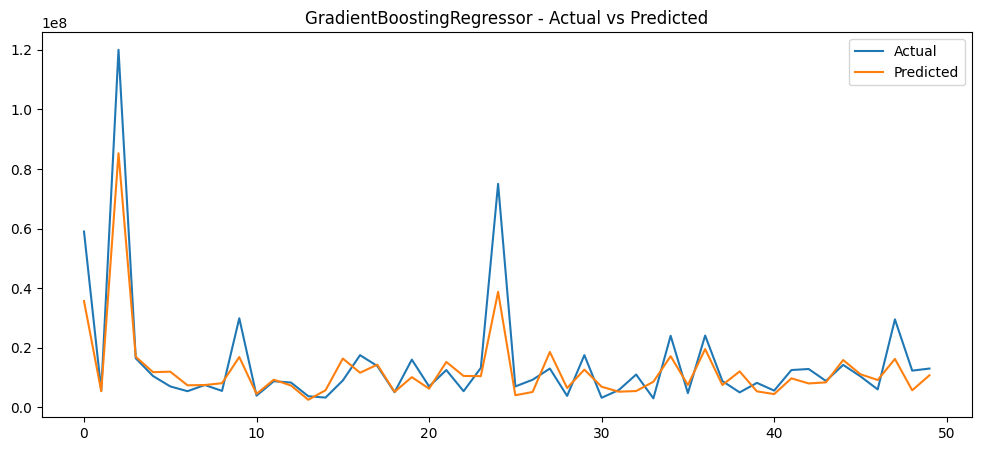


Training: ExtraTreesRegressor
R2 Train: 0.9938
R2 Test : 0.6703
RMSE Test: 13117593.2704


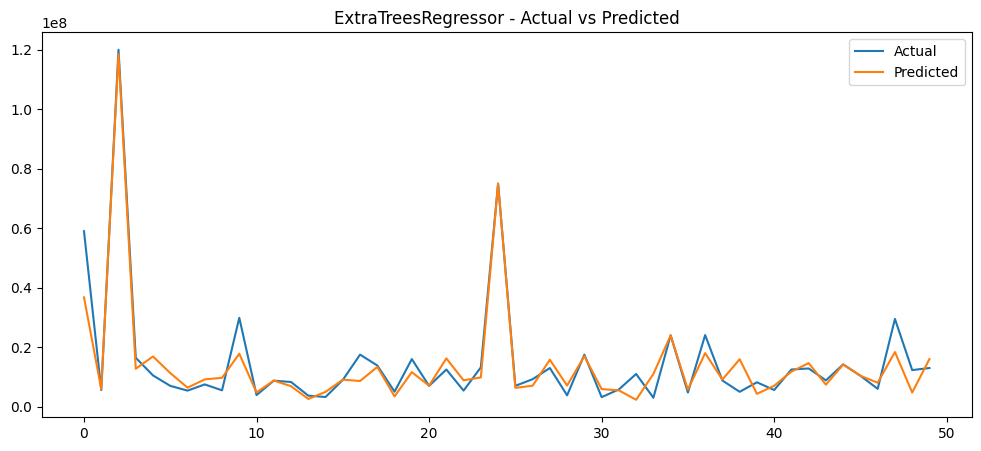


Training: XGBRegressor
R2 Train: 0.8027
R2 Test : 0.6806
RMSE Test: 12910302.9308


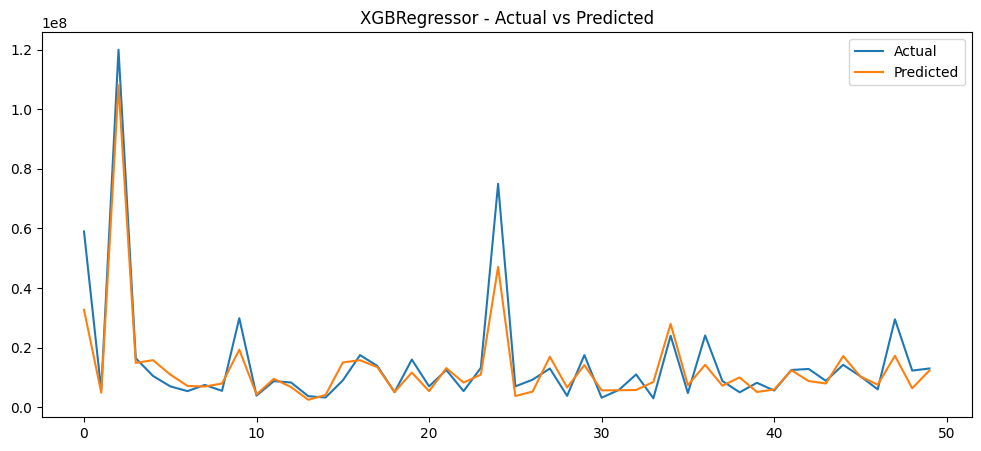


Training: LGBMRegressor
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000463 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 569
[LightGBM] [Info] Number of data points in the train set: 15414, number of used features: 14
[LightGBM] [Info] Start training from score 16.188354
R2 Train: 0.6828
R2 Test : 0.6277
RMSE Test: 13938921.2237


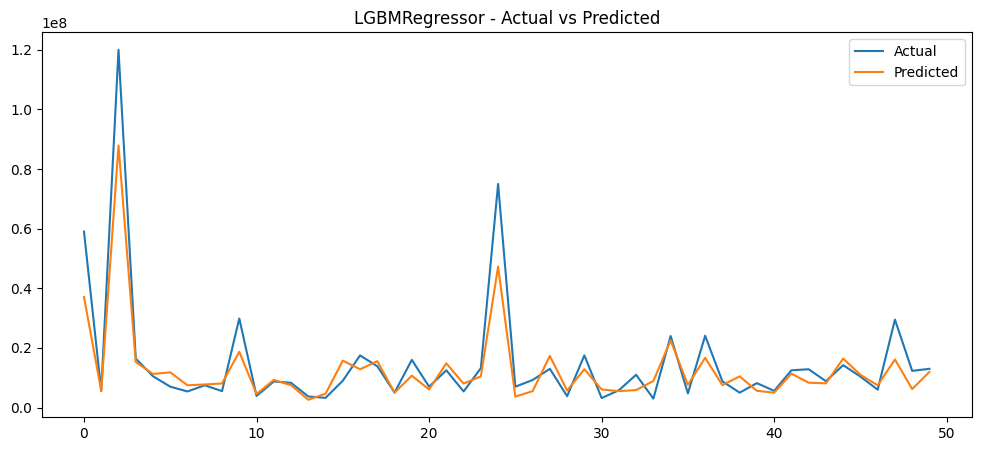


Training: CatBoostRegressor
R2 Train: 0.7437
R2 Test : 0.6826
RMSE Test: 12870967.5414


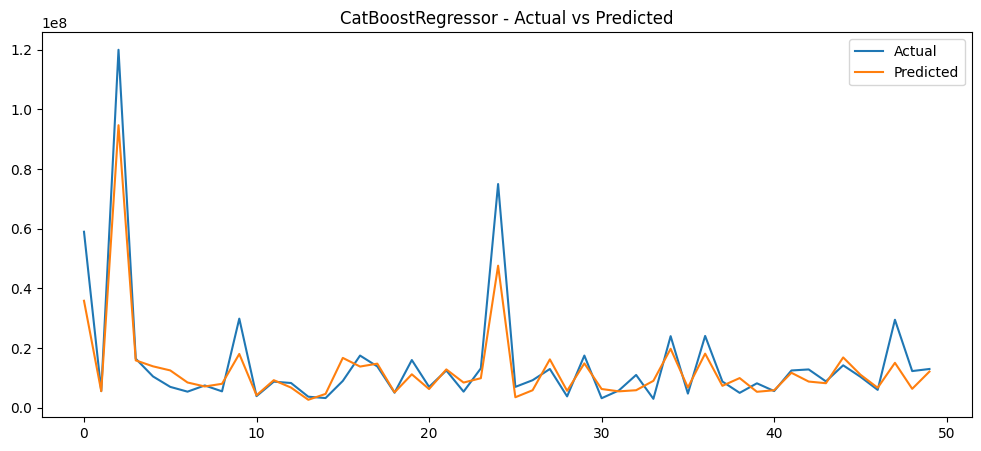


Training: KNeighborsRegressor
R2 Train: 0.6857
R2 Test : 0.5994
RMSE Test: 14459912.1836


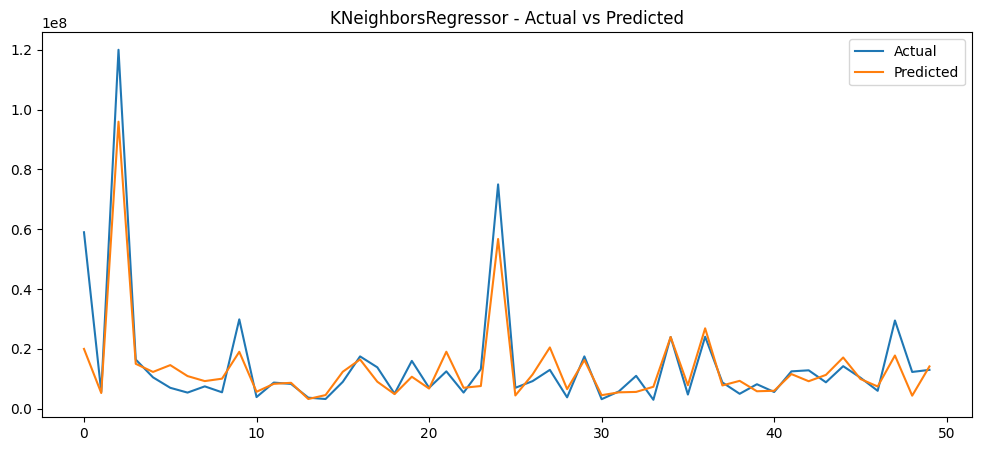


Training: SVR
R2 Train: 0.6331
R2 Test : 0.5722
RMSE Test: 14942176.8133


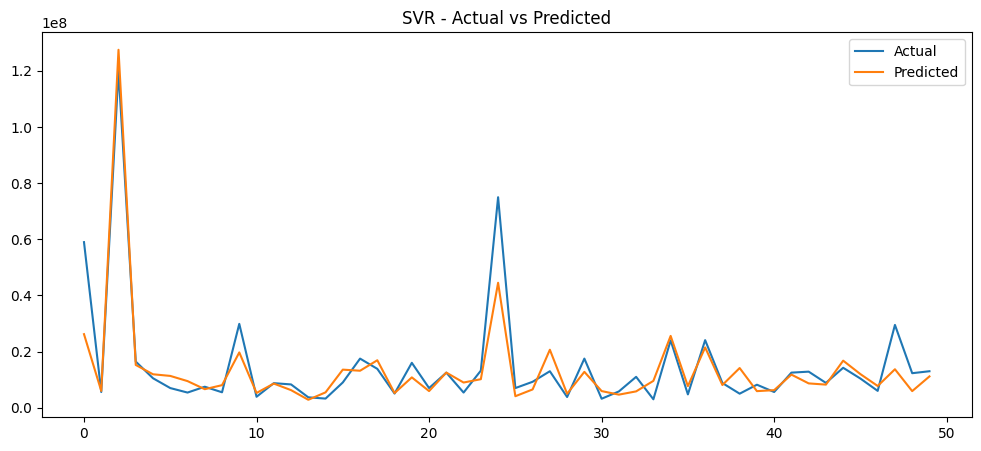


Training: LinearSVR
R2 Train: -0.2941
R2 Test : 0.5152
RMSE Test: 15906316.8015


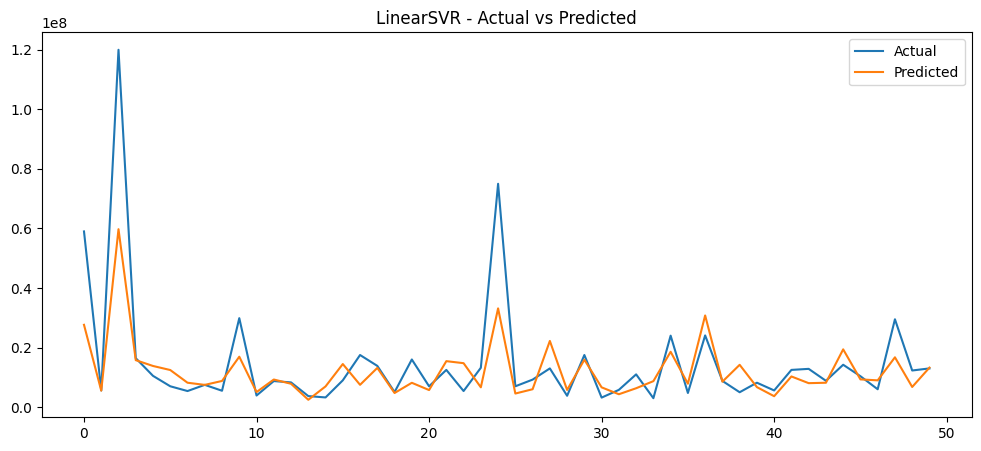


Training: MLPRegressor
R2 Train: 0.6403
R2 Test : 0.5880
RMSE Test: 14663247.1760


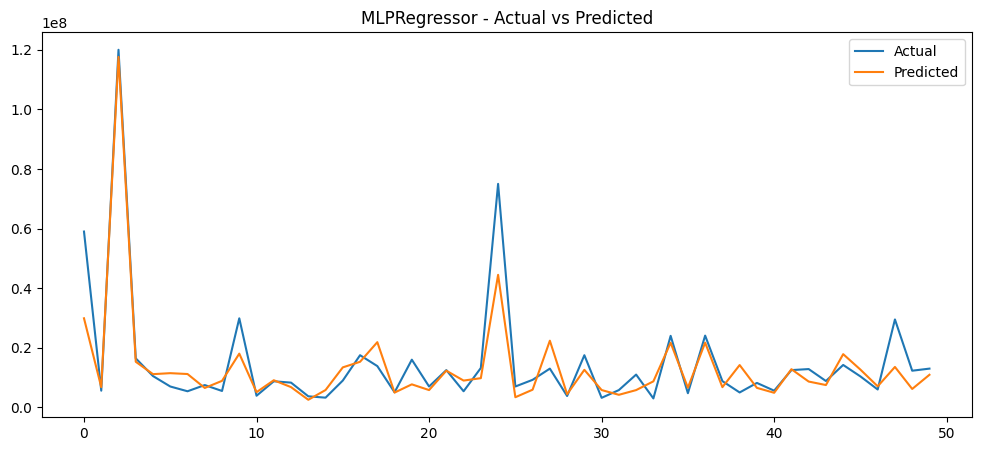

In [95]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

results = []

for name, model in models:

    print(f"\n{'='*50}")
    print(f"Training: {name}")

    # train test split
    X_train, X_test, y_train, y_test = train_test_split(
        x, y, test_size=0.2, random_state=42
    )
    steps = [
        ("Encoding",encoder),
        ("Scaling",StandardScaler()),
        ("Feature Selection",SelectFromModel(estimator=ExtraTreesRegressor(
            n_estimators=600, max_features=0.7,
            random_state=42, min_samples_leaf=5,
            min_samples_split=10 ,n_jobs=-1 ),
            threshold="median")),
        (f'{name}', model)
    ]

    model = Pipeline(steps)

    # fit
    model.fit(X_train, y_train)

    # predict (log scale)
    y_train_pred_log = model.predict(X_train)
    y_test_pred_log  = model.predict(X_test)

    # reverse log
    y_train_true = np.exp(y_train)
    y_test_true  = np.exp(y_test)

    y_train_pred = np.exp(y_train_pred_log)
    y_test_pred  = np.exp(y_test_pred_log)

    # metrics
    r2_train = r2_score(y_train_true, y_train_pred)
    r2_test  = r2_score(y_test_true, y_test_pred)

    rmse_test = np.sqrt(mean_squared_error(y_test_true, y_test_pred))

    print(f"R2 Train: {r2_train:.4f}")
    print(f"R2 Test : {r2_test:.4f}")
    print(f"RMSE Test: {rmse_test:.4f}")

    results.append((name, r2_test, rmse_test))

    # -------- Line Plot --------
    plt.figure(figsize=(12,5))

    plt.plot(y_test_true.values[:50], label="Actual")
    plt.plot(y_test_pred[:50], label="Predicted")

    plt.title(f"{name} - Actual vs Predicted")
    plt.legend()
    plt.show()